# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [168]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [169]:
corpus = '''
Born in the Greek city-state of Sparta, Kratos is the demigod son of the King of the Gods,
Zeus and to a mortal woman named Callisto. Because of this,
he has incredible intelligence, superhuman strength, and immense physical prowess.
However, he is left unaware of who his father was for most of his life.
Outraged at Zeus for fathering yet another bastard child,
Hera ordered Kratos' execution on the day he was born.

But as for the King of the Gods, he took pity on the child and refused, leaving Kratos in Sparta to be raised by Callisto.
Like all Spartan younglings, Kratos, with an incredible set of superhuman godly powers, (unknown that he is Zeus' son and the one whom he inherited the abilities),
was monitored and trained for combat by the Spartan authorities;
those who were deemed fit were to stay and be trained as Spartan warriors.
'''
print(corpus)


Born in the Greek city-state of Sparta, Kratos is the demigod son of the King of the Gods,
Zeus and to a mortal woman named Callisto. Because of this,
he has incredible intelligence, superhuman strength, and immense physical prowess.
However, he is left unaware of who his father was for most of his life.
Outraged at Zeus for fathering yet another bastard child,
Hera ordered Kratos' execution on the day he was born.

But as for the King of the Gods, he took pity on the child and refused, leaving Kratos in Sparta to be raised by Callisto.
Like all Spartan younglings, Kratos, with an incredible set of superhuman godly powers, (unknown that he is Zeus' son and the one whom he inherited the abilities),
was monitored and trained for combat by the Spartan authorities;
those who were deemed fit were to stay and be trained as Spartan warriors.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [170]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 92
X shape: (140, 26)
y shape: (140,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [171]:
rnn_model = Sequential([
    Embedding(total_words, 256, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [172]:
lstm_model = Sequential([
    Embedding(total_words, 256, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [173]:
gru_model = Sequential([
    Embedding(total_words, 256, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

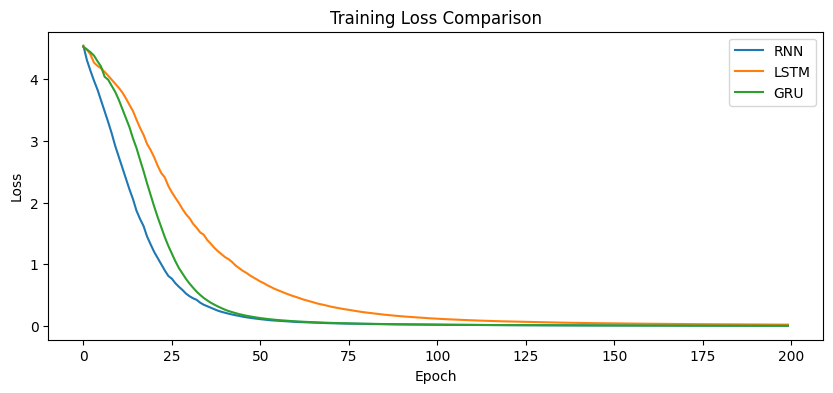

In [174]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [175]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [176]:
print("RNN :", generate_text(rnn_model, "Kratos", 10))
print("LSTM:", generate_text(lstm_model, "Kratos", 10))
print("GRU :", generate_text(gru_model, "Kratos", 10))

RNN : Kratos in the greek city state of sparta kratos is the
LSTM: Kratos in the greek city state of sparta kratos is the
GRU : Kratos in the greek city state of sparta kratos is the


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
- All models are performing poorly when embedding dimension is set to lower values.
- Output is getting better as the parameter is increased in the embedding layer.
- Training Time got increased.
- LSTM is performing better.
3. Increase epochs to 200
- Training time doubled.
4. Change hidden units 64 → 128
- Model is overfitted now.
- Required high computation power.
- All models are performing same now.
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**